In [1]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging_level = "ERROR"

# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
wavelengths = np.linspace(1.53, 1.57, 101)
freqs = pf.C_0 / wavelengths

LiveViewer started at http://localhost:64791


In [2]:
dual_mode_spec = siepic_tech.ports["TE_1550_500"].copy()
dual_mode_spec.num_modes = 2  # Use both modes

siepic_tech.add_port("TE-TM_1550_500", dual_mode_spec)
siepic_tech.ports["TE-TM_1550_500"]

PortSpec(description="Strip TE 1550 nm, w=500 nm", width=2, limits=(-1, 1.22), num_modes=2, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))])

In [3]:
class ThermalModel(pf.Model):
    def __init__(self, n_complex, voltage=0, coefficient=3e-4):
        super().__init__(
            n_complex=n_complex,
            voltage=voltage,
            coefficient=coefficient,
        )
        self.n_complex = np.array(n_complex, ndmin=2)
        self.voltage = voltage
        self.coefficient = coefficient

    def __copy__(self):
        return ThermalModel(self.n_complex, self.voltage, self.coefficient)

    def __deepcopy__(self, memo=None):
        # n_complex is an array, so we want to make sure to create a deep copy of it.
        # Other values (voltage and coefficient) are immutable (floats), so we can use them directly.
        return ThermalModel(self.n_complex.copy(), self.voltage, self.coefficient)

    def __repr__(self):
        return f"ThermalModel({self.n_complex!r}, {self.voltage!r}, {self.coefficient!r})"

    def __str__(self):
        return f"ThermalModel at {self.voltage} V"

    @property
    def as_bytes(self):
        coeffs = struct.pack("<2d", self.voltage, self.coefficient)
        shape = struct.pack("<2l", *self.n_complex.shape)
        n_data = self.n_complex.astype(complex).tobytes()
        # Add version 0 as first byte
        return b"\x00" + coeffs + shape + n_data

    @classmethod
    def from_bytes(cls, byte_repr):
        version = byte_repr[0]
        if version != 0:
            raise RuntimeError(f"Incompatible version for ThermalModel: {version}")

        byte_repr = byte_repr[1:]
        fmt = "<2d2l"
        head_len = struct.calcsize(fmt)
        voltage, coefficient, rows, cols = struct.unpack(fmt, byte_repr[:head_len])

        byte_repr = byte_repr[head_len:]
        n_complex = np.frombuffer(byte_repr, dtype=complex).reshape((rows, cols))

        return cls(n_complex, voltage, coefficient)

    @pf.cache_s_matrix
    def start(self, component, frequencies, voltage=None, **kwargs):
        # Allow overriding voltage as an `s_matrix` kwarg too
        if voltage is None:
            voltage = self.voltage
        n_complex = self.n_complex + self.coefficient * voltage**2
        wg_model = pf.WaveguideModel(n_complex)
        return wg_model.start(component, frequencies, **kwargs)


pf.register_model_class(ThermalModel)

In [4]:
@pf.parametric_component
def create_mzm(*, name, port_spec="TE_1550_500", coupling_distance=0.6, coupling_length=5.35, ps_length=100):

    # Bend and Straight waveguide to form the microring
    phase_shifter = pf.parametric.straight(name=f"ps", port_spec=port_spec, length=ps_length)
    straight = pf.parametric.straight(port_spec=port_spec, length=ps_length)
    bend = pf.parametric.bend(port_spec=port_spec, radius=5)
    coupler = pf.parametric.dual_ring_coupler(
        port_spec=port_spec, coupling_distance=coupling_distance, coupling_length=coupling_length, radius=5, 
        tidy3d_model_kwargs={
            # These symmetries are not correct for arbitrary ports.
            # They can be used in this case for the fundamental mode.
            "port_symmetries": [
                ("P1", "P0", "P3", "P2"),
                ("P2", "P3", "P0", "P1"),
                ("P3", "P2", "P1", "P0"),
            ],
        },
    )

    # Solve for the port mode of the waveguide and extract the complex refractive index
    alpha = 10
    kappa = (alpha * wavelengths * 1e-4 * np.log(10)) / (40 * np.pi)
    mode_solver = pf.port_modes(port=phase_shifter.ports["P0"], frequencies=freqs)
    n_complex = mode_solver.data.n_complex.values.T + 1j * kappa  # add propagation loss

    thermal_model = ThermalModel(n_complex=n_complex)
    phase_shifter.add_model(thermal_model, "Thermal")

    mzm = pf.Component(name)

    # form main microring structure
    cp1_ref = mzm.add_reference(coupler)
    cp2_ref = mzm.add_reference(coupler)
    ps1_ref = mzm.add_reference(phase_shifter)
    bend1_ref = mzm.add_reference(bend)
    bend2_ref = mzm.add_reference(bend) 
    bend3_ref = mzm.add_reference(bend)
    bend4_ref = mzm.add_reference(bend) 
    str1_ref = mzm.add_reference(straight)

    #Coupler Kiri
    bend1_ref.connect("P1", cp1_ref["P3"])
    bend2_ref.connect("P0", cp1_ref["P2"])
    #Tengah
    # trans1_ref.connect("P0", bend1_ref["P0"])
    ps1_ref.connect("P0", bend1_ref["P0"])
    str1_ref.connect("P0", bend2_ref["P1"])

    # trans2_ref.connect("P1", ps1_ref["P1"])
    bend3_ref.connect("P1", ps1_ref["P1"])
    bend4_ref.connect("P0", str1_ref["P1"])
    #Coupler Kanan
    cp2_ref.connect("P1", bend3_ref["P0"])
    cp2_ref.connect("P0", bend4_ref["P1"])


    # Define the heater and electrical path
    terminal_width = 10
    heater_width = 2

    heater = (
        pf.Path((ps1_ref.x_min, ps1_ref.y_mid), heater_width)
        .segment((ps1_ref.x_max, ps1_ref.y_mid), heater_width)
    )

    route_vp = (
        pf.Path((cp1_ref.x_mid-terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((cp1_ref.x_mid+terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((ps1_ref.x_min, ps1_ref.y_mid), heater_width)
    )

    route_vn = (
        pf.Path((ps1_ref.x_max, ps1_ref.y_mid), heater_width)
        .segment((cp2_ref.x_mid-terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((cp2_ref.x_mid+terminal_width/2, ps1_ref.y_mid), terminal_width)
    )

    mzm.add((11,0), heater)
    mzm.add((12,0), route_vp)
    mzm.add((12,0), route_vn)
    mzm.add_terminal(pf.Terminal((12,0), pf.Rectangle(size=(terminal_width, terminal_width), center=(cp1_ref.x_mid, ps1_ref.y_mid))), "VP")
    mzm.add_terminal(pf.Terminal((12,0), pf.Rectangle(size=(terminal_width, terminal_width), center=(cp2_ref.x_mid, ps1_ref.y_mid))), "VN")

    ## COMPONENT MODELS
    mzm.add_port(mzm.detect_ports([port_spec]))
    mzm.add_model(pf.CircuitModel(), "CircuitModel")

    port_symmetries = [
        ("P1", "P0", "P3", "P2"),
        ("P2", "P3", "P0", "P1"),
        ("P3", "P2", "P1", "P0"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    # mzm.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return mzm

# mzm = create_mzm(name="mzm", port_spec="TE-TM_1550_500", coupling_length=4.3)
# viewer(mzm)

In [5]:
@pf.parametric_component
def test_circuit(straight_length=50):
    component = pf.Component("test")

    straight = pf.parametric.straight(port_spec="TE_1550_500", length=straight_length)
    mzm = create_mzm(name="mzm", port_spec="TE_1550_500", coupling_length=5.35)
    coupler = pf.parametric.dual_ring_coupler(
        port_spec="TE_1550_500", coupling_distance=0.6, coupling_length=5.35, radius=5, 
        tidy3d_model_kwargs={
            # These symmetries are not correct for arbitrary ports.
            # They can be used in this case for the fundamental mode.
            "port_symmetries": [
                ("P1", "P0", "P3", "P2"),
                ("P2", "P3", "P0", "P1"),
                ("P3", "P2", "P1", "P0"),
            ],
        },
    )
    bend = pf.parametric.bend(port_spec="TE_1550_500", radius=5)

    str1_ref = component.add_reference(straight)
    bend_ref = component.add_reference(bend)
    cp_ref = component.add_reference(coupler)
    # mzm_ref = component.add_reference(mzm)

    bend_ref.connect("P1", str1_ref["P1"])
    cp_ref.connect("P1", bend_ref["P0"])
    # mzm_ref.connect("P1", bend_ref["P0"])

    component.add_port(component.detect_ports(["TE_1550_500"]))
    component.add_model(pf.CircuitModel(), "CircuitModel")

    return component
component = test_circuit(straight_length=10)
viewer(component)

Loading cached simulation from C:\Users\irfan\.tidy3d\pf_cache\A3W\ms_info-OTAQPFK7SKB24WNDRNFVMNY34ZE4H7RABCRWT6ROPGIPELNRGSUQ.json.
Progress: 100% 


Progress: 100% 


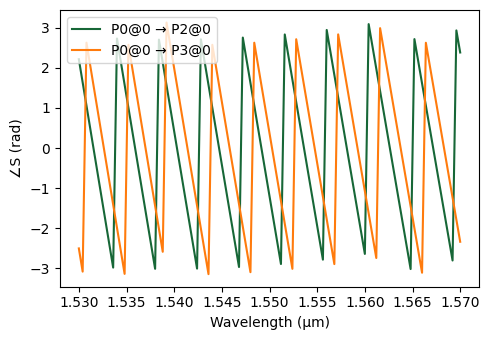

In [10]:
component = test_circuit(straight_length=100)
s_matrix = component.s_matrix(freqs)
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P2", "P3"], y="phase")

Progress: 100% 


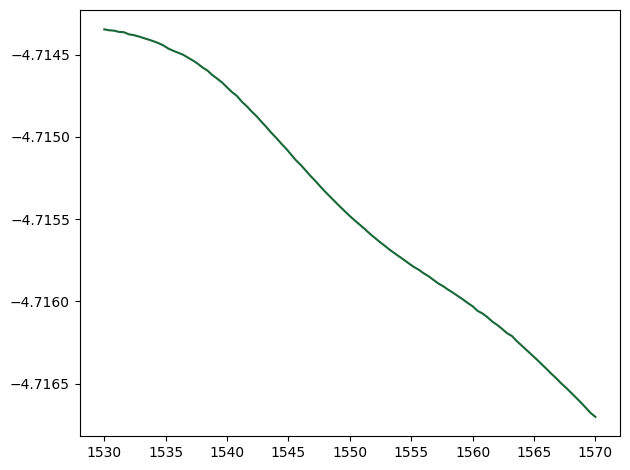

In [18]:
component = test_circuit(straight_length=100)
s_matrix = component.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
# fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P2", "P3"], y="phase")

fig, ax = plt.subplots()

phase0 = np.unwrap(np.angle(s_matrix[("P0@0", "P2@0")]))
phase1 = np.unwrap(np.angle(s_matrix[("P0@0", "P3@0")]))
delta = phase1 - phase0
ax.plot(wavelengths*1e3, delta, label="Phase Difference (P3 - P2)")

plt.tight_layout()
plt.show()

In [8]:
component = pf.Component("test")

straight = pf.parametric.straight(port_spec="TE-TM_1550_500", length=20)
y_branch = siepic.component("ebeam_y_1550")

# str1_ref = component.add_reference(straight)
# str2_ref = component.add_reference(straight)
# str3_ref = component.add_reference(straight)
# yb1_ref = component.add_reference(y_branch)

# yb1_ref.connect("P0", str1_ref["P1"])
# str2_ref.connect("P0", yb1_ref["P1"])
# str3_ref.connect("P0", yb1_ref["P2"])

# component.add_port(component.detect_ports(["TE-TM_1550_500"], on_boundary="x"))
# component.add_model(pf.CircuitModel(), "CircuitModel")

# # viewer(component)

# s_matrix = y_branch.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
# fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P1", "P2"])
y_branch.ports

{'P0': Port(center=(-7.4, 0), input_direction=0, spec=PortSpec(description="Strip TE 1550 nm, w=500 nm", width=2, limits=(-1, 1.22), num_modes=1, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))]), extended=True, inverted=False, bend_radius=0),
 'P1': Port(center=(7.4, -2.75), input_direction=180, spec=PortSpec(description="Strip TE 1550 nm, w=500 nm", width=2, limits=(-1, 1.22), num_modes=1, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))]), extended=True, inverted=False, bend_radius=0),
 'P2': Port(center=(7.4, 2.75), input_direction=180, spec=PortSpec(description="Strip TE 1550 nm, w=500 nm", width=2, limits=(-1, 1.22), num_modes=1, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))]), extended=True, inverted=False, bend_radius=0)}

In [ ]:
@pf.parametric_component
def create_y_branch(port_spec="TE-TM_1550_500", input_length=10, output_length=20, offset_up=5, offset_down=5):
    port_width = 0.5

    component = pf.Component("y_branch")

    sbend_up = pf.parametric.s_bend(port_spec=port_spec, length=output_length, offset=offset_up)
    sbend_down = pf.parametric.s_bend(port_spec=port_spec, length=output_length, offset=-offset_down)

    taper = pf.stencil.linear_taper(input_length, [port_width, port_width*2])
    component.add("Si", taper)

    sb1_ref = component.add_reference(sbend_up)
    sb2_ref = component.add_reference(sbend_down)
    sb1_ref.x_min = taper.x_max
    sb1_ref.y_min = taper.y_max - port_width
    sb2_ref.x_min = taper.x_max
    sb2_ref.y_max = taper.y_min + port_width

    port_symmetries = [
        ("P0", "P2", "P1"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    component.add_port(component.detect_ports([port_spec], on_boundary="x"))
    component.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return component

y_branch = create_y_branch()
viewer(y_branch)


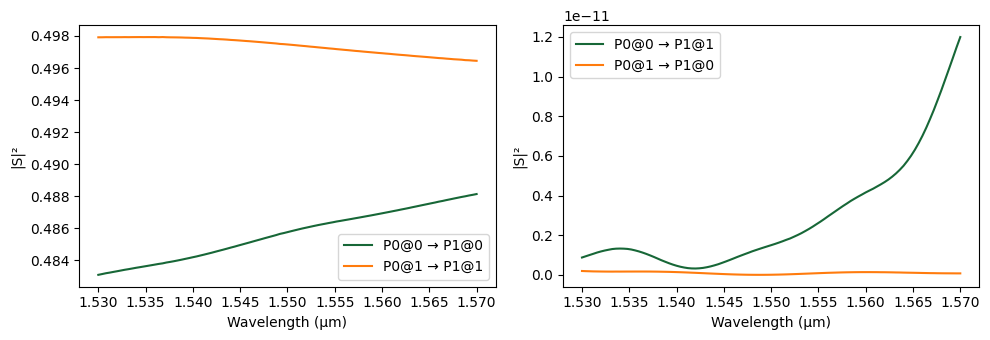

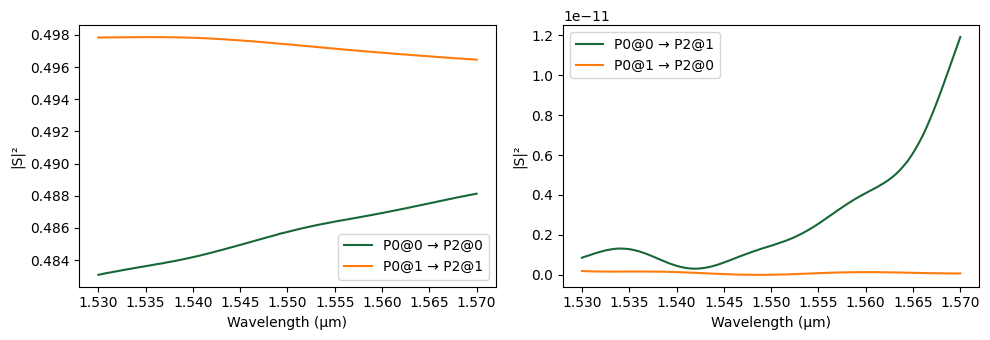

In [32]:
s_matrix = y_branch.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P1"], y="abs")
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P2"], y="abs")

In [51]:
crossing = pf.parametric.crossing(
    port_spec="TE_1550_500", arm_length=5, extra_length=0.5, added_width=1,
    tidy3d_model_kwargs={
        "port_symmetries": [
            ("P1", "P0", "P3", "P2"),
            ("P2", "P3", "P0", "P1"),
            ("P3", "P2", "P1", "P0"),
        ],
    }
)
viewer(crossing)
# s_matrix = crossing.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
# fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P1", "P2", "P3"], y="dB")